# Phase 1.5 v5 — v4 best 다중 자산 일반화 평가 (`05_multi_asset_evaluation.ipynb`)

> **목적**: v4 best (3ch_vix/IS=1250/emb=63) 가 SPY/QQQ 외 다양한 자산에서도
> HAR/EWMA/Naive 대비 우수성 유지하는지 검증.

## 종목 7종

| ticker | 명칭 | 카테고리 | VIX 효과 가설 |
|---|---|---|---|
| **SPY** | S&P 500 ETF | 미국 대형주 (baseline) | 강한 음의 상관 |
| **QQQ** | Nasdaq-100 ETF | 미국 기술주 | 강한 음의 상관 |
| **DIA** | Dow Jones ETF | 미국 대형주 (블루칩) | 강한 음의 상관 |
| **EEM** | MSCI Emerging Markets | 신흥국 주식 | 부분 상관 |
| **XLF** | Financial Sector | 미국 금융 섹터 | 강한 음의 상관 |
| **GOOGL** | Alphabet | 개별 주식 (기술) | 강한 음의 상관 |
| **WMT** | Walmart | 개별 주식 (방어주) | 약한 상관 |

## 모델 5종

| 모델 | 설명 |
|---|---|
| **v4 best LSTM** | 3ch_vix / IS=1250 / emb=63 (Phase 1.5 best 조합) |
| **HAR-RV** | Corsi 2009 학술 표준 |
| **EWMA** | RiskMetrics, λ=0.94 |
| **Naive** | 직전 trailing RV broadcast |
| **Train-Mean** | trivial baseline |

## 시각화 10+ 종류

§6.A ~ §6.J — 종합 비교 + 자산군별 패턴 + 종목 간 상관관계

## 사용자 GPU 환경 가이드

### Step 1. 라이브러리 설치 (필요 시)
```bash
pip install yfinance
```

### Step 2. 자동 데이터 다운로드
- 미보유 종목 (DIA, EEM, XLF, GOOGL, WMT) 자동 다운로드 + 캐시
- 약 ~30초

### Step 3. Run All
- 7 종목 × LSTM 학습 = ~6분 (GPU)
- 7 종목 × 베이스라인 = ~30초
- 시각화 + 분석 = ~1분
- **총 약 8~10분**

### 산출물
```
results/multi_asset/
├── SPY_v4_metrics.json (각 종목)
├── QQQ_v4_metrics.json
├── DIA_v4_metrics.json
├── EEM_v4_metrics.json
├── XLF_v4_metrics.json
├── GOOGL_v4_metrics.json
├── WMT_v4_metrics.json
└── multi_asset_comparison.csv (전 종목 × 모델 × 메트릭)

results/multi_asset_report.md (자동 생성)
```


## §1. 환경 + GPU + 라이브러리 import

### 라이브러리 설치 안내
```bash
pip install optuna yfinance
```


In [1]:
import sys
import json
import time
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

from scripts.setup import bootstrap, BASE_DIR, RAW_DATA_DIR, RESULTS_DIR
font_used = bootstrap()

try:
    import yfinance as yf
    print(f'yfinance {yf.__version__} 로드')
except ImportError:
    print('[ERROR] yfinance 미설치 — pip install yfinance')
    raise

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')


  Phase 1 — 환경 부트스트랩 완료
  한글 폰트  : Malgun Gothic
  시드       : 42
  결과 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results
yfinance 1.2.1 로드
사용 device: cuda
  GPU: NVIDIA GeForce RTX 4090


## §2. 다중 종목 데이터 다운로드 + VIX 로드

### 자동 처리
- `raw_data/{ticker}.csv` 캐시 존재? → 그대로 사용
- 미존재 → yfinance 자동 다운로드 + 캐시

기존 종목: SPY, QQQ, VIX
신규 종목: DIA, EEM, XLF, GOOGL, WMT


In [2]:
import pandas as pd
import numpy as np

TICKERS = ['SPY', 'QQQ', 'DIA', 'EEM', 'XLF', 'GOOGL', 'WMT']
ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2025-12-31'
DOWNLOAD_START = '2009-01-01'
DOWNLOAD_END   = '2026-04-30'


def load_or_download_ticker(ticker: str) -> pd.DataFrame:
    """캐시 우선, 미존재 시 yfinance 다운로드."""
    csv_path = RAW_DATA_DIR / f'{ticker}.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True).sort_index()
        print(f'  [캐시] {ticker}: {df.index[0].date()} ~ {df.index[-1].date()}, n={len(df)}')
    else:
        print(f'  [다운로드] {ticker}...')
        df = yf.download(ticker, start=DOWNLOAD_START, end=DOWNLOAD_END,
                          progress=False, auto_adjust=False)
        if df.empty:
            raise RuntimeError(f'{ticker} 다운로드 실패')
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [c[0] for c in df.columns]
        df.index.name = 'Date'
        df.to_csv(csv_path)
        print(f'  [저장] {csv_path}')
    return df


# 모든 종목 로드 / 다운로드
print('=' * 70)
print('종목 데이터 로드 / 다운로드')
print('=' * 70)
ticker_data = {}
for tk in TICKERS:
    ticker_data[tk] = load_or_download_ticker(tk)


# VIX 로드 (이미 v4 에서 다운로드됨)
print()
print('VIX 로드')
vix_path = RAW_DATA_DIR / 'VIX.csv'
df_vix_full = pd.read_csv(vix_path, index_col=0, parse_dates=True).sort_index()
vix_col = 'Close' if 'Close' in df_vix_full.columns else df_vix_full.columns[0]
df_vix_full = df_vix_full[[vix_col]].rename(columns={vix_col: 'VIX'})
print(f'  VIX: {df_vix_full.index[0].date()} ~ {df_vix_full.index[-1].date()}, n={len(df_vix_full)}')


종목 데이터 로드 / 다운로드
  [캐시] SPY: 2009-01-02 ~ 2026-03-30, n=4336
  [캐시] QQQ: 2009-01-02 ~ 2026-03-30, n=4336
  [다운로드] DIA...
  [저장] C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\raw_data\DIA.csv
  [다운로드] EEM...
  [저장] C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\raw_data\EEM.csv
  [다운로드] XLF...
  [저장] C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\raw_data\XLF.csv
  [다운로드] GOOGL...
  [저장] C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\raw_data\GOOGL.csv
  [다운로드] WMT...
  [저장] C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\raw_data\WMT.csv

VIX 로드
  VIX: 2009-01-02 ~ 2026-04-24, n=4354


## §3. 종목별 입력 채널 + 타깃 사전 준비


In [3]:
from scripts.targets_volatility import build_daily_target_logrv_21d

WINDOW = 21
SEQ_LEN = 63
HAR_W_WINDOW = 5
HAR_M_WINDOW = 22


def prepare_ticker_df(raw: pd.DataFrame) -> pd.DataFrame:
    """분석 기간 절단 + log_ret + HAR + VIX + 타깃 모두 사전 준비."""
    df = raw.loc[ANALYSIS_START:ANALYSIS_END].copy()
    df['log_ret'] = np.log(df['Adj Close']).diff()
    df = df.join(df_vix_full, how='left')
    df['VIX'] = df['VIX'].ffill()
    df['rv_d'] = df['log_ret'].abs()
    df['rv_w'] = (df['log_ret'] ** 2).rolling(HAR_W_WINDOW).mean().pow(0.5)
    df['rv_m'] = (df['log_ret'] ** 2).rolling(HAR_M_WINDOW).mean().pow(0.5)
    df['vix_log'] = np.log(df['VIX'])
    df['rv_trailing'] = df['log_ret'].rolling(WINDOW).std(ddof=1)
    df['target_logrv'] = build_daily_target_logrv_21d(df['Adj Close'], window=WINDOW)
    return df


print('=' * 80)
print('종목별 데이터 준비 + 통계')
print('=' * 80)
analysis_dict = {}
print(f'  {"ticker":<8} {"n":>6} {"valid_target":>12} {"mean_RV":>10} {"std_RV":>10}')
print('  ' + '-' * 55)
for tk in TICKERS:
    df = prepare_ticker_df(ticker_data[tk])
    analysis_dict[tk] = df
    n = len(df)
    n_valid = int(df['target_logrv'].notna().sum())
    mean_rv = float(df['rv_trailing'].mean())
    std_rv = float(df['rv_trailing'].std())
    print(f'  {tk:<8} {n:>6} {n_valid:>12} {mean_rv:>10.5f} {std_rv:>10.5f}')

# 유효 타깃 수 (모든 종목 동일 가정)
N_VALID = min(int(analysis_dict[tk]['target_logrv'].notna().sum()) for tk in TICKERS)
print(f'\nN_VALID (min): {N_VALID}')


종목별 데이터 준비 + 통계
  ticker        n valid_target    mean_RV     std_RV
  -------------------------------------------------------
  SPY        2514         2493    0.00941    0.00648
  QQQ        2514         2493    0.01234    0.00698
  DIA        2514         2493    0.00896    0.00665
  EEM        2514         2493    0.01158    0.00571
  XLF        2514         2493    0.01190    0.00763
  GOOGL      2514         2493    0.01684    0.00712
  WMT        2514         2493    0.01205    0.00634

N_VALID (min): 2493


## §4. 학습 함수 — v4 best 와 베이스라인 모두

### v4 best config (고정)
- input_channels = '3ch_vix' (input_size=4)
- IS = 1250, embargo = 63, hidden = 32, dropout = 0.3, lr = 1e-3


In [4]:
from torch.utils.data import TensorDataset, DataLoader
from scripts.dataset import build_fold_datasets, walk_forward_folds
from scripts.models import LSTMRegressor
from scripts.train import train_one_fold
from scripts.baselines_volatility import (
    fit_har_rv, predict_ewma, predict_naive, predict_train_mean,
)
from scripts.metrics_volatility import (
    rmse, mae, qlike, r2_train_mean, mz_regression, pred_std_ratio,
    summarize_folds_volatility,
)

# v4 best hyperparameter
INPUT_SIZE = 4
HIDDEN = 32
NUM_LAYERS = 1
DROPOUT = 0.3
LR = 1e-3
WEIGHT_DECAY = 1e-3
MAX_EPOCHS = 30
PATIENCE = 5
LR_PATIENCE = 3
LOSS_TYPE = 'mse'
BATCH_SIZE = 32
VAL_RATIO = 0.2
SEED = 42

IS_LEN = 1250
PURGE = 21
EMBARGO = 63
OOS_LEN = 21
STEP = 21


def build_input_3ch_vix(df: pd.DataFrame):
    series = df['rv_d'].fillna(0.0).values
    extra = np.column_stack([
        df['rv_w'].fillna(0.0).values,
        df['rv_m'].fillna(0.0).values,
        df['vix_log'].fillna(method='ffill').fillna(0.0).values,
    ])
    return series, extra


def build_train_val_loaders(train_ds, val_ratio=VAL_RATIO, batch_size=BATCH_SIZE):
    n = len(train_ds)
    n_val = max(1, int(n * val_ratio))
    n_tr = n - n_val
    train_sub = TensorDataset(train_ds.X[:n_tr], train_ds.y[:n_tr])
    val_sub   = TensorDataset(train_ds.X[n_tr:], train_ds.y[n_tr:])
    tr_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(val_sub, batch_size=max(1, n_val), shuffle=False)
    return tr_loader, va_loader


def train_lstm_v4_for_ticker(ticker: str, df: pd.DataFrame, folds: list):
    """단일 종목 v4 best LSTM 학습 + fold_predictions 반환."""
    series, extra = build_input_3ch_vix(df)
    target = df['target_logrv'].values

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if device.type == 'cuda':
        torch.cuda.manual_seed_all(SEED)

    fold_out = []
    t_start = time.time()
    for k, (tr_idx, te_idx) in enumerate(folds):
        tr_ds_k, te_ds_k, _ = build_fold_datasets(
            series=series, train_idx=tr_idx, test_idx=te_idx,
            seq_len=SEQ_LEN, extra_features=extra, target_series=target,
        )
        tr_loader, va_loader = build_train_val_loaders(tr_ds_k)
        model_k = LSTMRegressor(
            input_size=INPUT_SIZE, hidden_size=HIDDEN,
            num_layers=NUM_LAYERS, dropout=DROPOUT, batch_first=True,
        )
        result = train_one_fold(
            model_k, tr_loader, va_loader,
            max_epochs=MAX_EPOCHS, early_stop_patience=PATIENCE,
            lr=LR, weight_decay=WEIGHT_DECAY, lr_patience=LR_PATIENCE,
            loss_type=LOSS_TYPE, device=device, verbose=False,
        )
        model_k.load_state_dict(result['best_state_dict'])
        model_k.to(device).eval()
        with torch.no_grad():
            y_pred = model_k(te_ds_k.X.to(device)).cpu().numpy().flatten()
        y_true = te_ds_k.y.numpy()
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        fold_out.append({
            'fold': k,
            'test_idx_first': int(te_idx[0]), 'test_idx_last': int(te_idx[-1]),
            'y_true_test': y_true.astype(float).tolist(),
            'y_pred_test': y_pred.astype(float).tolist(),
            'best_epoch': int(result['best_epoch']),
            'best_val_loss': float(result['best_val_loss']),
        })
    elapsed = time.time() - t_start
    print(f'  [{ticker}] LSTM v4 best 학습 완료 ({len(folds)} fold, {elapsed:.0f}s)')
    return fold_out


def run_baselines_for_ticker(ticker: str, df: pd.DataFrame, folds: list):
    """단일 종목 베이스라인 4종 학습."""
    log_ret = df['log_ret']
    target = df['target_logrv']
    rv_trailing = df['rv_trailing']

    out = {'har': [], 'ewma': [], 'naive': [], 'train_mean': []}
    t_start = time.time()
    for k, (tr_idx, te_idx) in enumerate(folds):
        y_true = target.values[te_idx]
        # HAR
        y_pred_har, _ = fit_har_rv(log_ret, tr_idx, te_idx, horizon=WINDOW)
        out['har'].append({'y_true': y_true.astype(float).tolist(),
                           'y_pred': y_pred_har.astype(float).tolist()})
        # EWMA
        y_pred_ewma = predict_ewma(log_ret, tr_idx, te_idx, horizon=WINDOW, lam=0.94)
        out['ewma'].append({'y_true': y_true.astype(float).tolist(),
                            'y_pred': y_pred_ewma.astype(float).tolist()})
        # Naive
        y_pred_naive = predict_naive(rv_trailing, tr_idx, te_idx)
        out['naive'].append({'y_true': y_true.astype(float).tolist(),
                             'y_pred': y_pred_naive.astype(float).tolist()})
        # Train-Mean
        y_pred_tm = predict_train_mean(target, tr_idx, te_idx)
        out['train_mean'].append({'y_true': y_true.astype(float).tolist(),
                                  'y_pred': y_pred_tm.astype(float).tolist()})
    elapsed = time.time() - t_start
    print(f'  [{ticker}] 베이스라인 4종 완료 ({elapsed:.1f}s)')
    return out


print('학습 함수 정의 완료')


학습 함수 정의 완료


## §5. 7 종목 학습 실행

⚠️ **시간**: GPU 환경 약 ~6~7분 (LSTM) + ~30초 (베이스라인)


In [5]:
# Walk-Forward fold 생성 (모든 종목 동일)
folds = walk_forward_folds(
    n=N_VALID, is_len=IS_LEN, purge=PURGE, emb=EMBARGO,
    oos_len=OOS_LEN, step=STEP,
)
N_FOLDS = len(folds)
print(f'fold 수 (모든 종목 공통): {N_FOLDS}')


# 7 종목 × LSTM v4 + 베이스라인 학습
print()
print('=' * 80)
print('7 종목 × LSTM v4 best + 베이스라인 4종 학습')
print('=' * 80)

lstm_results = {}
baseline_results = {}
t_total_start = time.time()

for i, tk in enumerate(TICKERS):
    print(f'\n[{i+1}/{len(TICKERS)}] {tk}')
    df = analysis_dict[tk]
    lstm_results[tk] = train_lstm_v4_for_ticker(tk, df, folds)
    baseline_results[tk] = run_baselines_for_ticker(tk, df, folds)

t_total_elapsed = time.time() - t_total_start
print(f'\n{"=" * 80}')
print(f'전체 학습 완료 — 총 {t_total_elapsed/60:.1f}분')
print(f'{"=" * 80}')


fold 수 (모든 종목 공통): 55

7 종목 × LSTM v4 best + 베이스라인 4종 학습

[1/7] SPY


C:\Users\gorhk\AppData\Local\Temp\ipykernel_35396\2733971352.py:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,


  [SPY] LSTM v4 best 학습 완료 (55 fold, 77s)
  [SPY] 베이스라인 4종 완료 (0.1s)

[2/7] QQQ


C:\Users\gorhk\AppData\Local\Temp\ipykernel_35396\2733971352.py:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,


  [QQQ] LSTM v4 best 학습 완료 (55 fold, 75s)
  [QQQ] 베이스라인 4종 완료 (0.1s)

[3/7] DIA


...

  [XLF] LSTM v4 best 학습 완료 (55 fold, 80s)
  [XLF] 베이스라인 4종 완료 (0.1s)

[6/7] GOOGL


C:\Users\gorhk\AppData\Local\Temp\ipykernel_35396\2733971352.py:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,


  [GOOGL] LSTM v4 best 학습 완료 (55 fold, 71s)
  [GOOGL] 베이스라인 4종 완료 (0.1s)

[7/7] WMT


C:\Users\gorhk\AppData\Local\Temp\ipykernel_35396\2733971352.py:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,


  [WMT] LSTM v4 best 학습 완료 (55 fold, 75s)
  [WMT] 베이스라인 4종 완료 (0.1s)

전체 학습 완료 — 총 8.6분


## §6. 메트릭 계산 + 종합 비교 표


In [6]:
def compute_metrics_for_fold_list(fold_list_y_true_pred):
    """fold 별 metrics 계산."""
    per_fold = []
    for fold_data in fold_list_y_true_pred:
        y_true = np.array(fold_data['y_true'] if 'y_true' in fold_data else fold_data['y_true_test'])
        y_pred = np.array(fold_data['y_pred'] if 'y_pred' in fold_data else fold_data['y_pred_test'])
        # Train-Mean baseline (각 fold 의 train mean) 은 외부에서 별도 계산 필요
        # 본 함수는 단일 모델 메트릭만
        mz = mz_regression(y_true, y_pred)
        per_fold.append({
            'rmse': rmse(y_true, y_pred),
            'mae': mae(y_true, y_pred),
            'qlike': qlike(y_true, y_pred),
            'pred_std_ratio': pred_std_ratio(y_true, y_pred),
            'mz_alpha': mz['alpha'], 'mz_beta': mz['beta'], 'mz_r2': mz['r2'],
        })
    return per_fold


# 종합 결과 dict
all_results = {}   # {ticker: {model: per_fold_metrics}}

for tk in TICKERS:
    df = analysis_dict[tk]
    target = df['target_logrv']

    # LSTM v4 best
    lstm_per_fold = compute_metrics_for_fold_list(lstm_results[tk])
    # r2_train_mean 추가 (LSTM)
    for k, fp in enumerate(lstm_results[tk]):
        y_true = np.array(fp['y_true_test'])
        y_pred = np.array(fp['y_pred_test'])
        # train mean 은 fold 의 train_idx 의 target 평균
        tr_idx = folds[k][0]
        y_train = target.values[tr_idx]
        y_train = y_train[np.isfinite(y_train)]
        lstm_per_fold[k]['r2_train_mean'] = r2_train_mean(y_true, y_pred, y_train)

    # 베이스라인 4종
    bl_per_fold = {m: compute_metrics_for_fold_list(baseline_results[tk][m])
                    for m in ['har', 'ewma', 'naive', 'train_mean']}
    # r2_train_mean 추가 (각 모델)
    for m in ['har', 'ewma', 'naive', 'train_mean']:
        for k, fp in enumerate(baseline_results[tk][m]):
            y_true = np.array(fp['y_true'])
            y_pred = np.array(fp['y_pred'])
            tr_idx = folds[k][0]
            y_train = target.values[tr_idx]
            y_train = y_train[np.isfinite(y_train)]
            bl_per_fold[m][k]['r2_train_mean'] = r2_train_mean(y_true, y_pred, y_train)

    all_results[tk] = {
        'lstm_v4': lstm_per_fold,
        'har':       bl_per_fold['har'],
        'ewma':      bl_per_fold['ewma'],
        'naive':     bl_per_fold['naive'],
        'train_mean': bl_per_fold['train_mean'],
    }


# 종합 summary
summary_dict = {}
for tk in TICKERS:
    summary_dict[tk] = {m: summarize_folds_volatility(all_results[tk][m])
                         for m in ['lstm_v4', 'har', 'ewma', 'naive', 'train_mean']}


# 종합 표 (RMSE 기준)
print('=' * 95)
print('종목 × 모델 × RMSE (90 fold mean)')
print('=' * 95)
MODELS = ['lstm_v4', 'har', 'ewma', 'naive', 'train_mean']
print(f'  {"ticker":<8}', end='')
for m in MODELS:
    print(f'  {m:>11}', end='')
print()
print('  ' + '-' * 75)
for tk in TICKERS:
    print(f'  {tk:<8}', end='')
    for m in MODELS:
        rmse_m = summary_dict[tk][m]['rmse']['mean']
        print(f'  {rmse_m:>11.4f}', end='')
    # 1위 모델
    rmses = [(m, summary_dict[tk][m]['rmse']['mean']) for m in MODELS]
    best_m = min(rmses, key=lambda x: x[1])
    print(f'   ← best: {best_m[0]}')


종목 × 모델 × RMSE (90 fold mean)
  ticker        lstm_v4          har         ewma        naive   train_mean
  ---------------------------------------------------------------------------
  SPY            0.3208       0.3239       0.3363       0.3563       0.4078   ← best: lstm_v4
  QQQ            0.2921       0.2920       0.2996       0.3075       0.3860   ← best: har
  DIA            0.2963       0.3060       0.3055       0.3320       0.3513   ← best: lstm_v4
  EEM            0.2546       0.2662       0.2900       0.3128       0.2867   ← best: lstm_v4
  XLF            0.3088       0.3164       0.3204       0.3433       0.3670   ← best: lstm_v4
  GOOGL          0.2827       0.2850       0.3132       0.3489       0.3087   ← best: lstm_v4
  WMT            0.3364       0.3269       0.3588       0.3890       0.3354   ← best: har


## §7. 시각화 — 10+ 종류 다양하게


### §7.A. RMSE Heatmap (종목 × 모델)


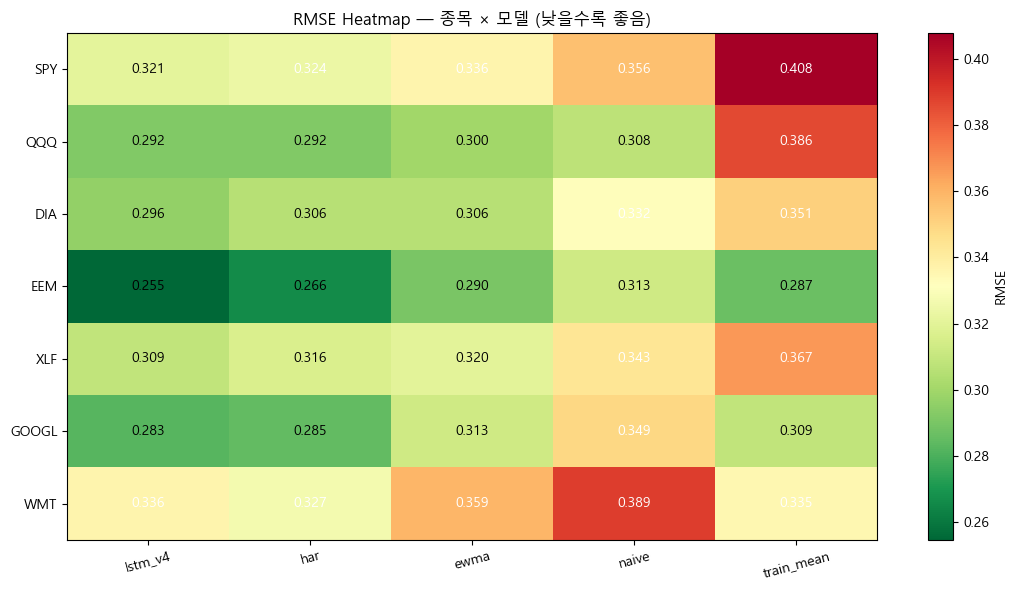

In [7]:
import matplotlib.pyplot as plt

# RMSE matrix
rmse_matrix = np.zeros((len(TICKERS), len(MODELS)))
for i, tk in enumerate(TICKERS):
    for j, m in enumerate(MODELS):
        rmse_matrix[i, j] = summary_dict[tk][m]['rmse']['mean']

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(rmse_matrix, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels(MODELS, rotation=15)
ax.set_yticks(range(len(TICKERS)))
ax.set_yticklabels(TICKERS)
for i in range(len(TICKERS)):
    for j in range(len(MODELS)):
        ax.text(j, i, f'{rmse_matrix[i,j]:.3f}', ha='center', va='center',
                color='white' if rmse_matrix[i,j] > rmse_matrix.mean() else 'black',
                fontsize=10)
ax.set_title('RMSE Heatmap — 종목 × 모델 (낮을수록 좋음)')
plt.colorbar(im, ax=ax, label='RMSE')
plt.tight_layout()
plt.show()


### §7.B. QLIKE Heatmap (위험관리 손실)


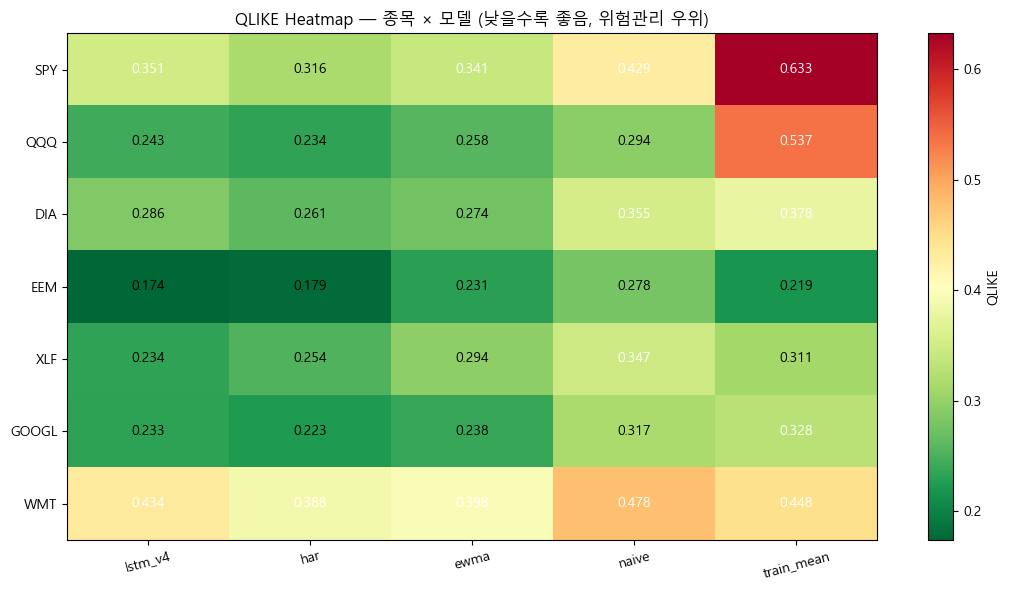

In [8]:
qlike_matrix = np.zeros((len(TICKERS), len(MODELS)))
for i, tk in enumerate(TICKERS):
    for j, m in enumerate(MODELS):
        qlike_matrix[i, j] = summary_dict[tk][m]['qlike']['mean']

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(qlike_matrix, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels(MODELS, rotation=15)
ax.set_yticks(range(len(TICKERS)))
ax.set_yticklabels(TICKERS)
for i in range(len(TICKERS)):
    for j in range(len(MODELS)):
        ax.text(j, i, f'{qlike_matrix[i,j]:.3f}', ha='center', va='center',
                color='white' if qlike_matrix[i,j] > qlike_matrix.mean() else 'black',
                fontsize=10)
ax.set_title('QLIKE Heatmap — 종목 × 모델 (낮을수록 좋음, 위험관리 우위)')
plt.colorbar(im, ax=ax, label='QLIKE')
plt.tight_layout()
plt.show()


### §7.C. 종목별 RMSE Bar (모델 비교)


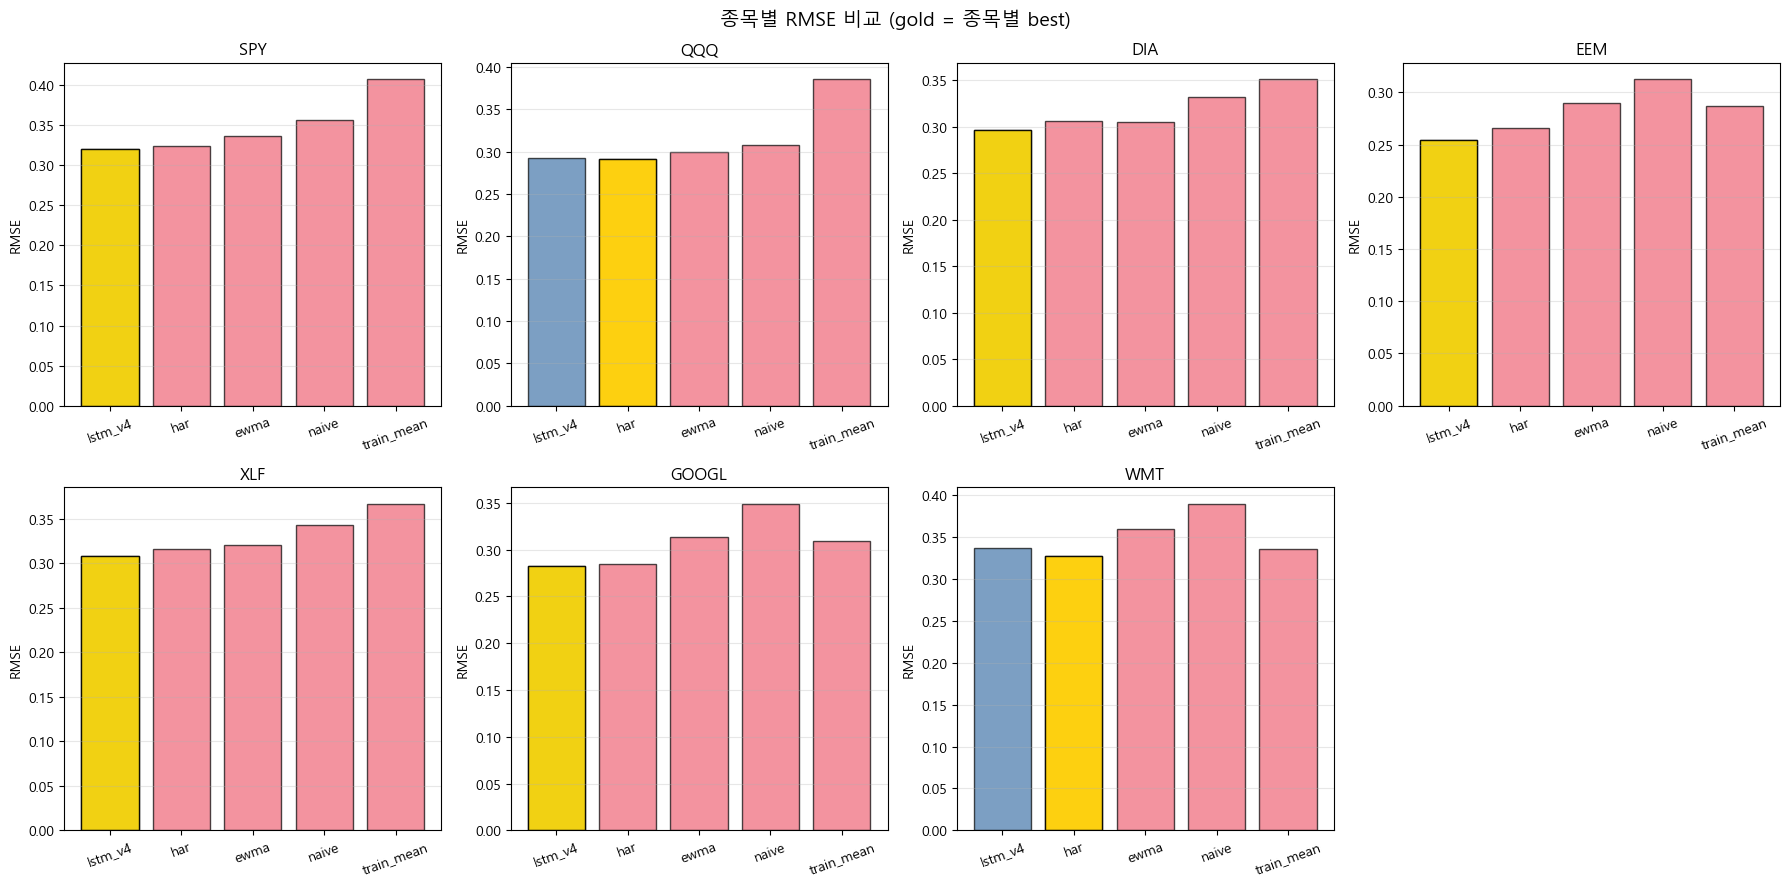

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, tk in enumerate(TICKERS):
    ax = axes[i]
    rmses = [summary_dict[tk][m]['rmse']['mean'] for m in MODELS]
    colors = ['#4477AA' if m == 'lstm_v4' else '#EE6677' for m in MODELS]
    ax.bar(MODELS, rmses, color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(f'{tk}')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(alpha=0.3, axis='y')
    # best 모델 highlight
    min_rmse = min(rmses)
    best_idx = rmses.index(min_rmse)
    ax.bar(MODELS[best_idx], min_rmse, color='gold', alpha=0.9, edgecolor='black')
# 마지막 빈 axis 숨김
for j in range(len(TICKERS), len(axes)):
    axes[j].axis('off')
plt.suptitle('종목별 RMSE 비교 (gold = 종목별 best)', fontsize=14)
plt.tight_layout()
plt.show()


### §7.D. 모델별 RMSE 박스플롯 (전 종목 분포)


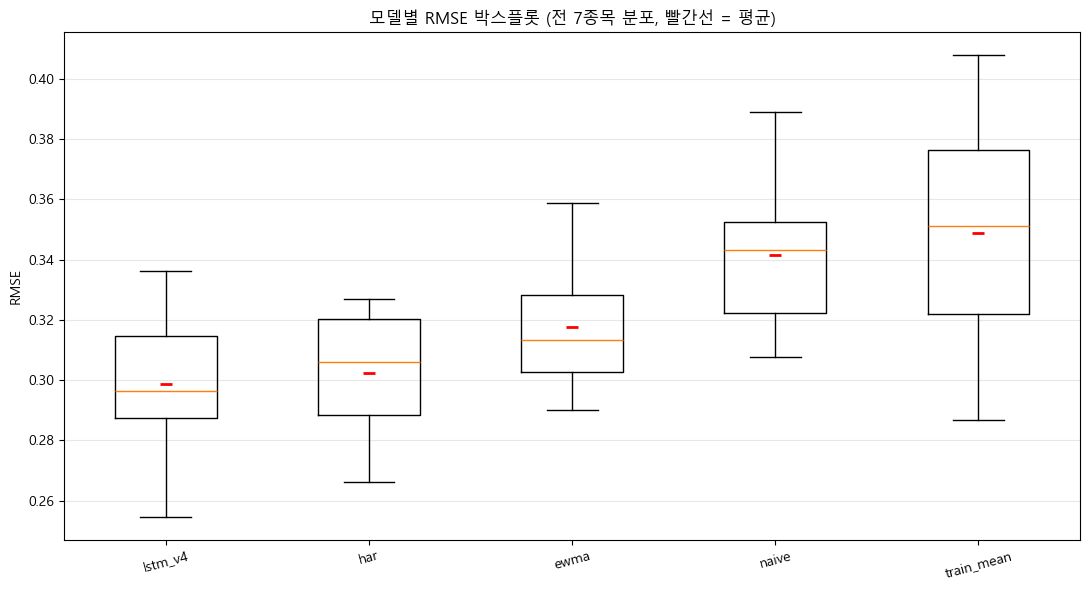

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
data = []
for m in MODELS:
    model_rmses = [summary_dict[tk][m]['rmse']['mean'] for tk in TICKERS]
    data.append(model_rmses)
ax.boxplot(data, tick_labels=MODELS)
# 평균선 추가
for i, m in enumerate(MODELS):
    avg = np.mean(data[i])
    ax.scatter(i+1, avg, color='red', s=80, marker='_', linewidth=2, zorder=10)
ax.set_title('모델별 RMSE 박스플롯 (전 7종목 분포, 빨간선 = 평균)')
ax.set_ylabel('RMSE')
ax.tick_params(axis='x', rotation=15)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### §7.E. 자산군별 평균 RMSE 비교


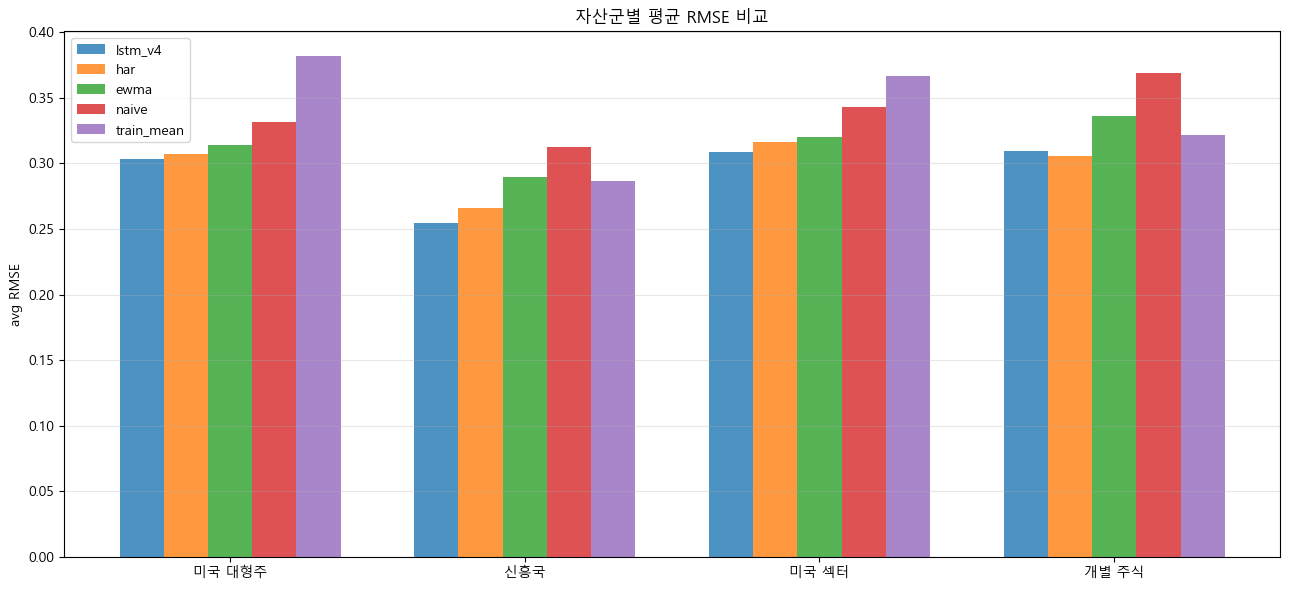

In [11]:
# 자산군 분류
ASSET_GROUPS = {
    '미국 대형주':  ['SPY', 'QQQ', 'DIA'],
    '신흥국':      ['EEM'],
    '미국 섹터':   ['XLF'],
    '개별 주식':   ['GOOGL', 'WMT'],
}

fig, ax = plt.subplots(figsize=(13, 6))
group_names = list(ASSET_GROUPS.keys())
n_groups = len(group_names)
n_models = len(MODELS)
bar_width = 0.15
x = np.arange(n_groups)
for j, m in enumerate(MODELS):
    avg_rmse = []
    for g, tickers_in_g in ASSET_GROUPS.items():
        rmses = [summary_dict[tk][m]['rmse']['mean'] for tk in tickers_in_g]
        avg_rmse.append(np.mean(rmses))
    ax.bar(x + j * bar_width, avg_rmse, bar_width, label=m, alpha=0.8)
ax.set_xticks(x + bar_width * (n_models - 1) / 2)
ax.set_xticklabels(group_names)
ax.set_ylabel('avg RMSE')
ax.set_title('자산군별 평균 RMSE 비교')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### §7.F. v4 best vs HAR fold 별 산점도 (종목별 1:1 비교)


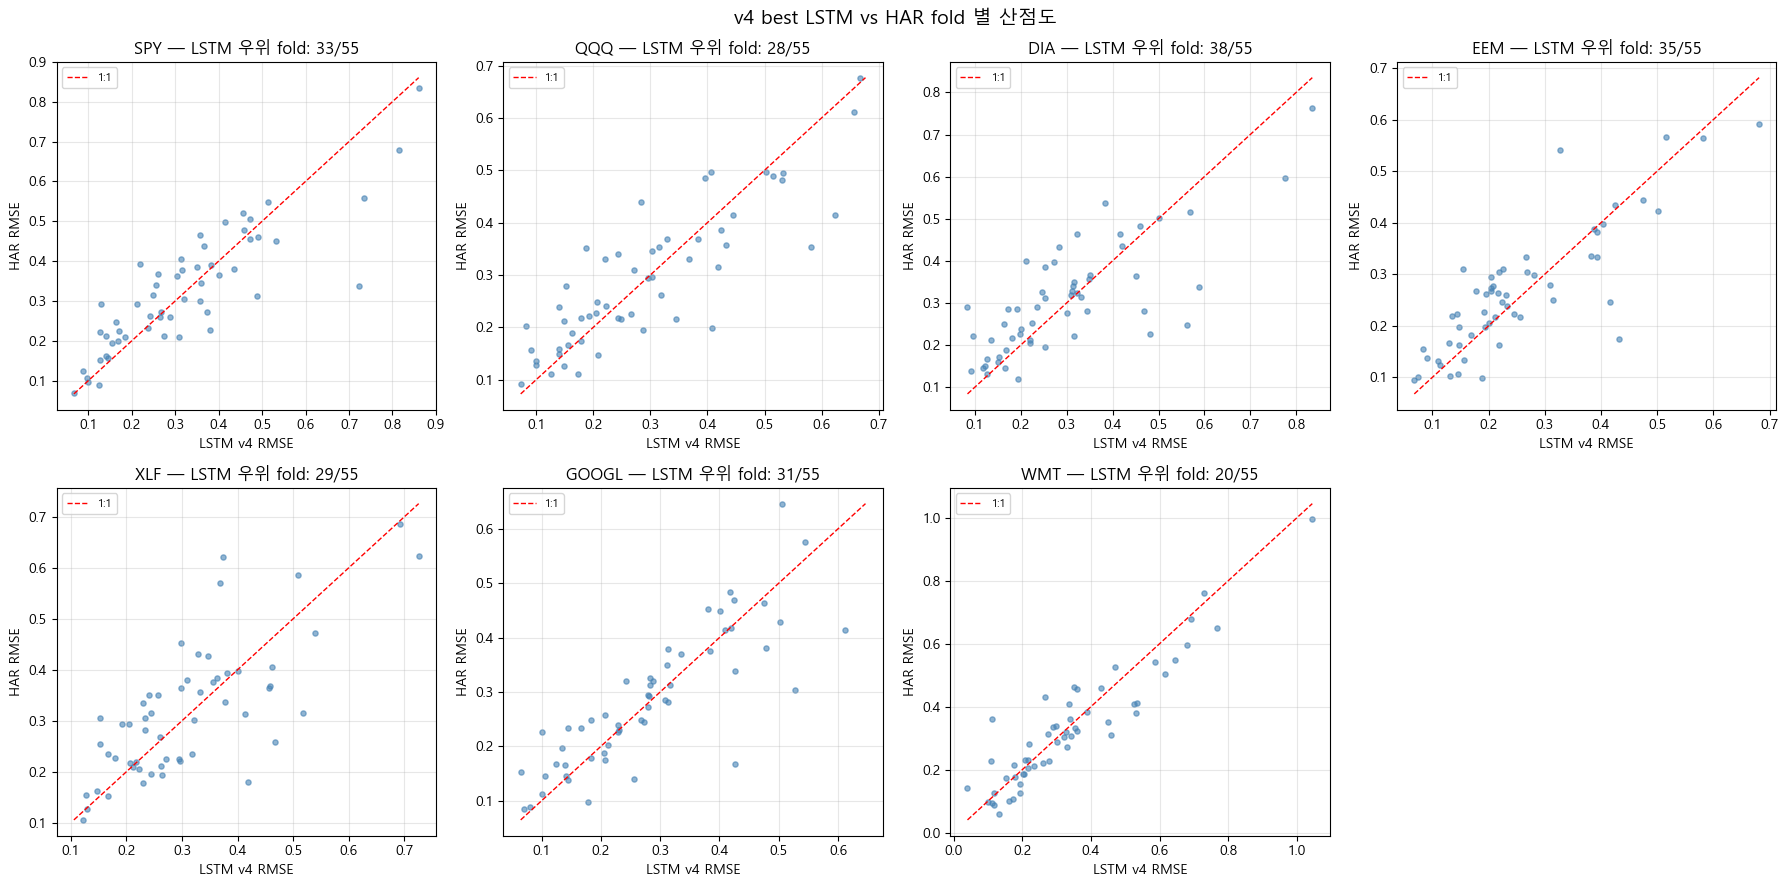

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, tk in enumerate(TICKERS):
    ax = axes[i]
    lstm_rmses = [d['rmse'] for d in all_results[tk]['lstm_v4']]
    har_rmses  = [d['rmse'] for d in all_results[tk]['har']]
    ax.scatter(lstm_rmses, har_rmses, s=14, alpha=0.6, color='steelblue')
    lo = min(min(lstm_rmses), min(har_rmses))
    hi = max(max(lstm_rmses), max(har_rmses))
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1, label='1:1')
    n_lstm_better = sum(1 for l, h in zip(lstm_rmses, har_rmses) if l < h)
    ax.set_title(f'{tk} — LSTM 우위 fold: {n_lstm_better}/{len(lstm_rmses)}')
    ax.set_xlabel('LSTM v4 RMSE')
    ax.set_ylabel('HAR RMSE')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
for j in range(len(TICKERS), len(axes)):
    axes[j].axis('off')
plt.suptitle('v4 best LSTM vs HAR fold 별 산점도', fontsize=14)
plt.tight_layout()
plt.show()


### §7.G. 종목별 best_epoch 분포 (학습 안정성)


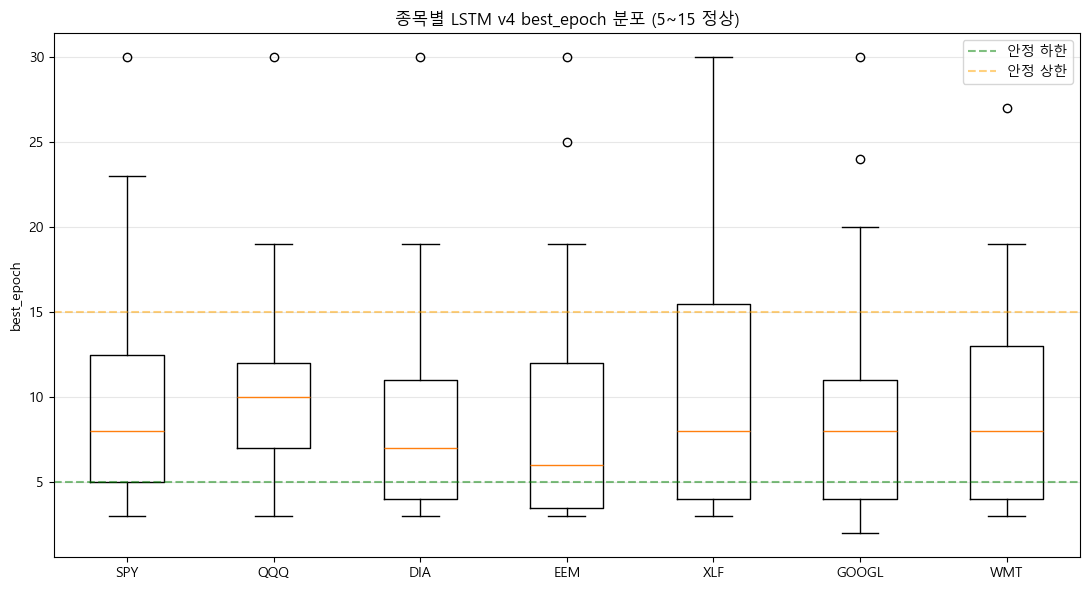

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
data = []
for tk in TICKERS:
    epochs = [fp['best_epoch'] for fp in lstm_results[tk]]
    data.append(epochs)
ax.boxplot(data, tick_labels=TICKERS)
ax.axhline(5, color='green', ls='--', alpha=0.5, label='안정 하한')
ax.axhline(15, color='orange', ls='--', alpha=0.5, label='안정 상한')
ax.set_title('종목별 LSTM v4 best_epoch 분포 (5~15 정상)')
ax.set_ylabel('best_epoch')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### §7.H. 종목별 변동성 분포 + v4 예측 분포 비교


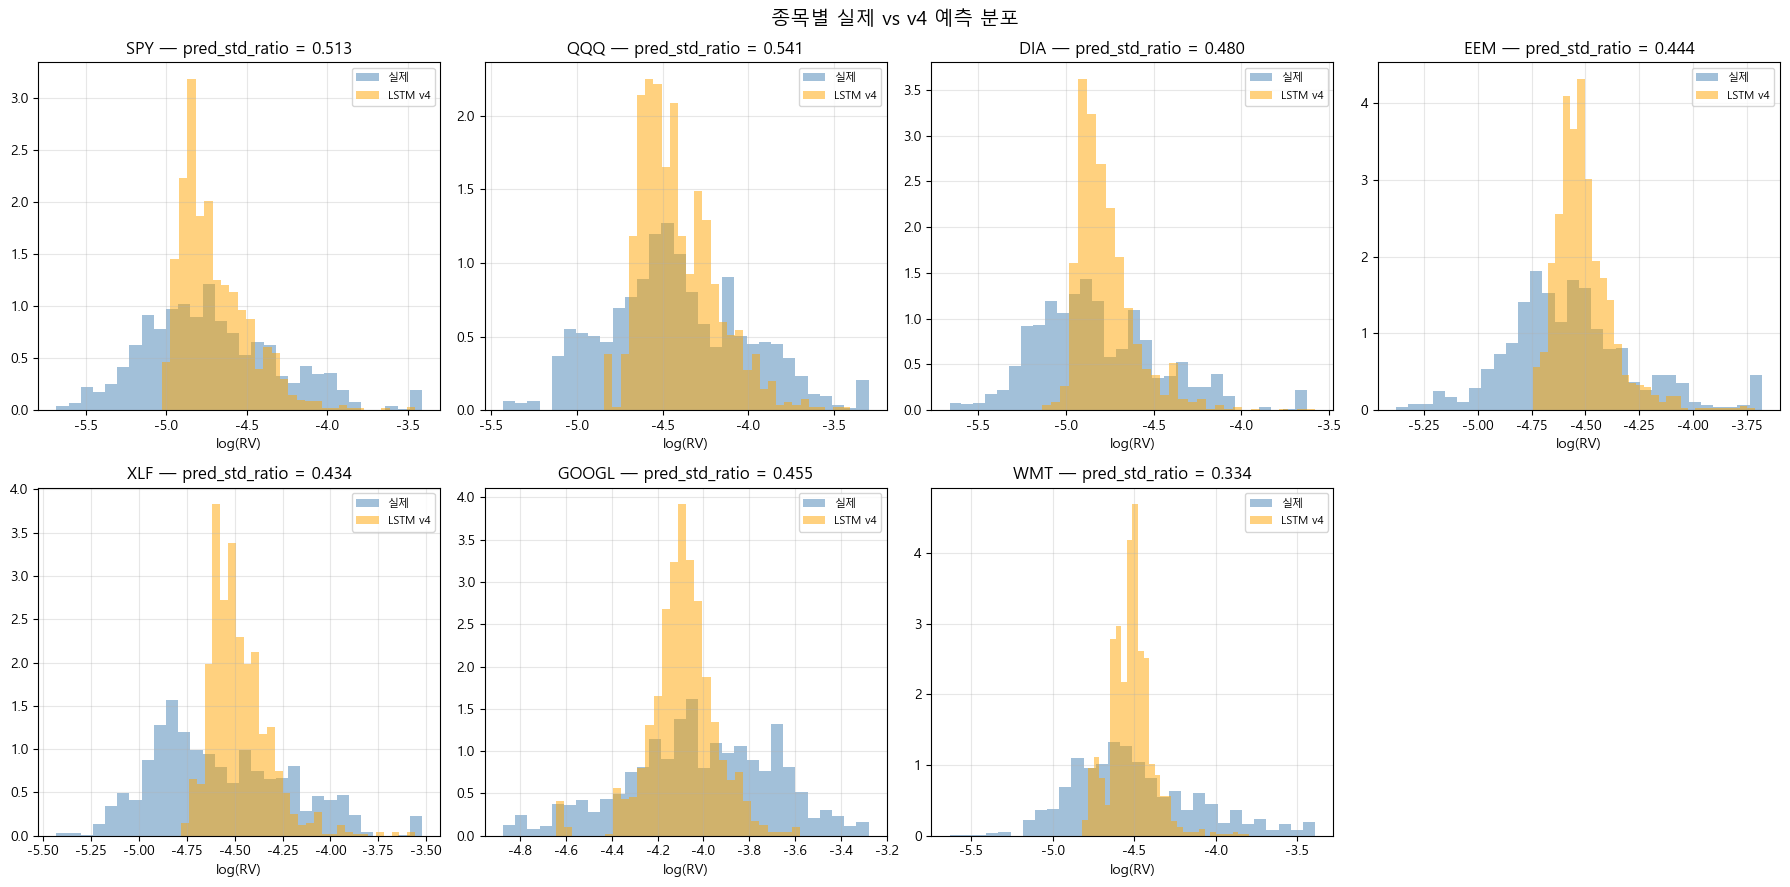

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, tk in enumerate(TICKERS):
    ax = axes[i]
    all_true = np.concatenate([fp['y_true_test'] for fp in lstm_results[tk]])
    all_pred = np.concatenate([fp['y_pred_test'] for fp in lstm_results[tk]])
    ax.hist(all_true, bins=30, alpha=0.5, label='실제', color='steelblue', density=True)
    ax.hist(all_pred, bins=30, alpha=0.5, label='LSTM v4', color='orange', density=True)
    ratio = all_pred.std() / all_true.std() if all_true.std() > 0 else float('nan')
    ax.set_title(f'{tk} — pred_std_ratio = {ratio:.3f}')
    ax.set_xlabel('log(RV)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
for j in range(len(TICKERS), len(axes)):
    axes[j].axis('off')
plt.suptitle('종목별 실제 vs v4 예측 분포', fontsize=14)
plt.tight_layout()
plt.show()


### §7.I. 종목 간 잔차 상관 Heatmap (v4 best)


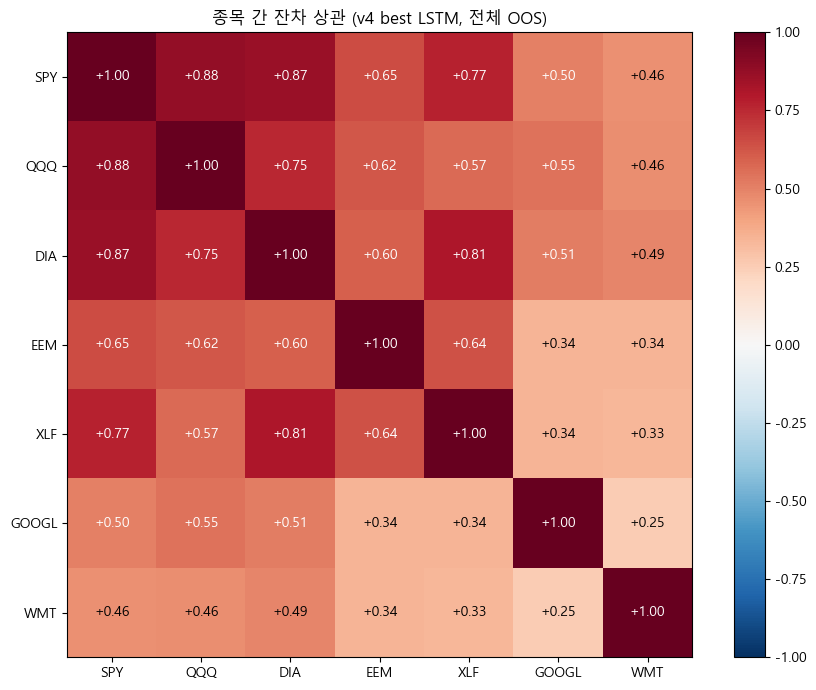

In [15]:
# 각 종목의 잔차 시계열 (전체 OOS)
residual_dict = {}
for tk in TICKERS:
    res = []
    for fp in lstm_results[tk]:
        y_true = np.array(fp['y_true_test'])
        y_pred = np.array(fp['y_pred_test'])
        res.append(y_true - y_pred)
    residual_dict[tk] = np.concatenate(res)

# 종목별 잔차 길이 동일성 확인
n_min = min(len(r) for r in residual_dict.values())
res_matrix = np.array([residual_dict[tk][:n_min] for tk in TICKERS])

# 상관 행렬
corr_matrix = np.corrcoef(res_matrix)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f'{corr_matrix[i,j]:+.2f}', ha='center', va='center',
                color='white' if abs(corr_matrix[i,j]) > 0.5 else 'black', fontsize=10)
ax.set_xticks(range(len(TICKERS)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(TICKERS)
ax.set_yticklabels(TICKERS)
ax.set_title('종목 간 잔차 상관 (v4 best LSTM, 전체 OOS)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### §7.J. RMSE vs 평균 변동성 산점도 (자산 특성과 모델 성능 관계)


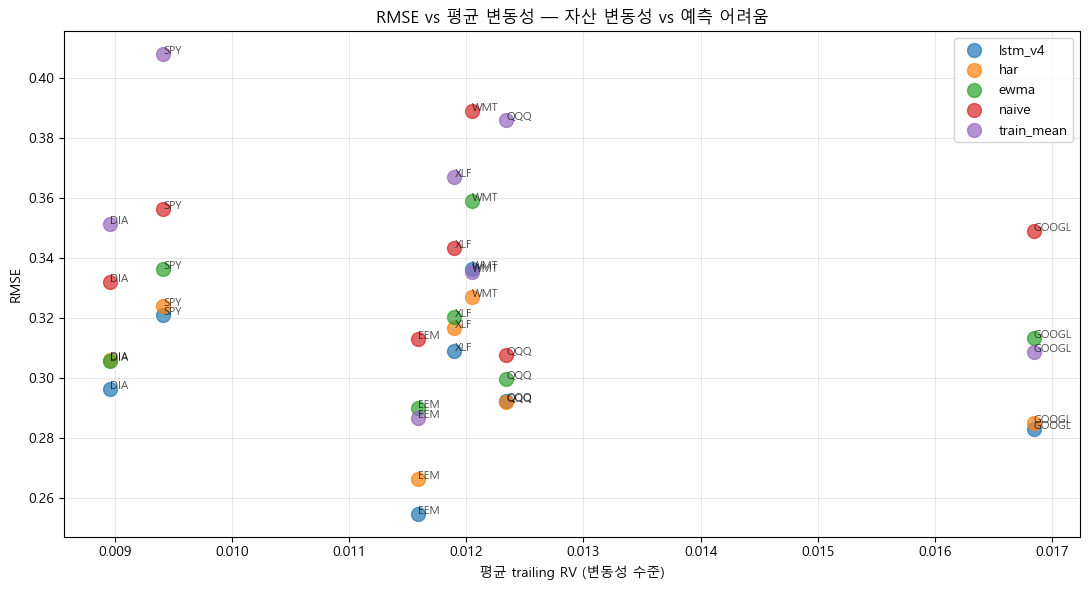

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))
for m in MODELS:
    rmses = [summary_dict[tk][m]['rmse']['mean'] for tk in TICKERS]
    avg_vols = [analysis_dict[tk]['rv_trailing'].mean() for tk in TICKERS]
    ax.scatter(avg_vols, rmses, s=100, alpha=0.7, label=m)
    # 종목명 annotate
    for tk, v, r in zip(TICKERS, avg_vols, rmses):
        ax.annotate(tk, (v, r), fontsize=8, alpha=0.7)
ax.set_xlabel('평균 trailing RV (변동성 수준)')
ax.set_ylabel('RMSE')
ax.set_title('RMSE vs 평균 변동성 — 자산 변동성 vs 예측 어려움')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### §7.K. 모델별 PASS 조건 충족도 (관문 1, 3 종합)


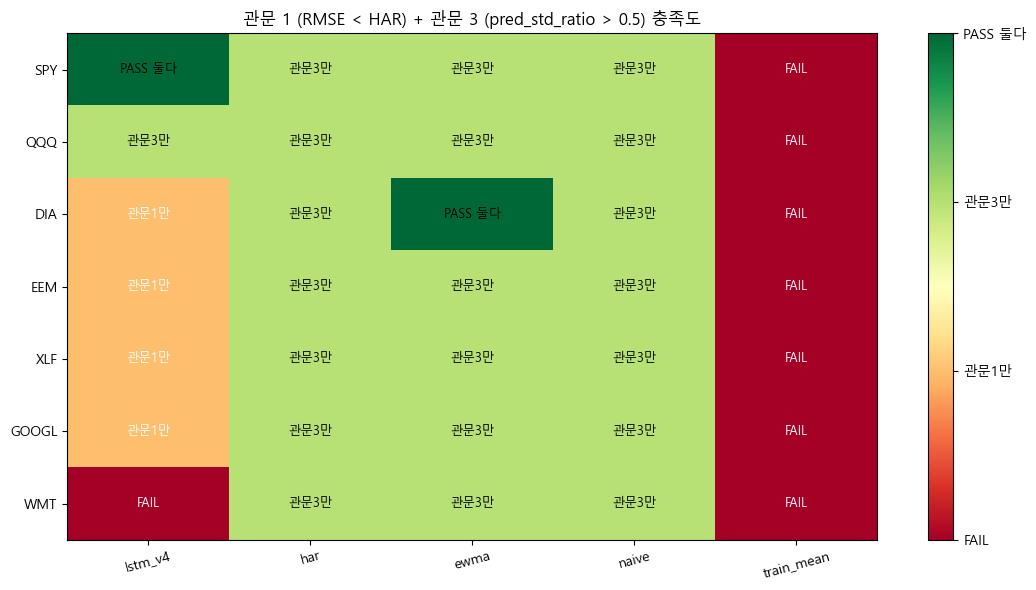

In [17]:
# 관문 충족 여부 (HAR baseline 대비 RMSE, pred_std_ratio > 0.5)
gate_matrix = np.zeros((len(TICKERS), len(MODELS)))   # 0=FAIL, 1=관문1만, 2=관문3만, 3=둘다
for i, tk in enumerate(TICKERS):
    har_rmse = summary_dict[tk]['har']['rmse']['mean']
    for j, m in enumerate(MODELS):
        rmse_m = summary_dict[tk][m]['rmse']['mean']
        psr_m  = summary_dict[tk][m]['pred_std_ratio']['mean']
        gate1 = rmse_m < har_rmse
        gate3 = psr_m > 0.5
        gate_matrix[i, j] = int(gate1) + int(gate3) * 2  # 0,1,2,3

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(gate_matrix, cmap='RdYlGn', vmin=0, vmax=3, aspect='auto')
labels = {0: 'FAIL', 1: '관문1만', 2: '관문3만', 3: 'PASS 둘다'}
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels(MODELS, rotation=15)
ax.set_yticks(range(len(TICKERS)))
ax.set_yticklabels(TICKERS)
for i in range(len(TICKERS)):
    for j in range(len(MODELS)):
        ax.text(j, i, labels[int(gate_matrix[i,j])], ha='center', va='center',
                color='white' if gate_matrix[i,j] in (0, 1) else 'black', fontsize=9)
ax.set_title('관문 1 (RMSE < HAR) + 관문 3 (pred_std_ratio > 0.5) 충족도')
plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], format=plt.FuncFormatter(lambda x, _: labels[int(x)]))
plt.tight_layout()
plt.show()


## §8. 종합 결론 + 저장


In [18]:
# 종합 비교 CSV 저장
OUT_DIR = RESULTS_DIR / 'multi_asset'
OUT_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for tk in TICKERS:
    for m in MODELS:
        s = summary_dict[tk][m]
        rows.append({
            'ticker': tk, 'model': m,
            'rmse_mean': s['rmse']['mean'], 'rmse_std': s['rmse']['std'],
            'qlike_mean': s['qlike']['mean'], 'qlike_std': s['qlike']['std'],
            'r2_train_mean': s['r2_train_mean']['mean'],
            'pred_std_ratio': s['pred_std_ratio']['mean'],
            'mae_mean': s['mae']['mean'],
        })
df_comparison = pd.DataFrame(rows)
csv_path = OUT_DIR / 'multi_asset_comparison.csv'
df_comparison.to_csv(csv_path, index=False)
print(f'저장: {csv_path}')


# 종목별 v4 metrics.json 저장 (개별 분석용)
import json
for tk in TICKERS:
    out = {
        'ticker': tk,
        'lstm_v4_per_fold': all_results[tk]['lstm_v4'],
        'baselines_per_fold': {m: all_results[tk][m] for m in ['har', 'ewma', 'naive', 'train_mean']},
        'summary': summary_dict[tk],
        'fold_predictions_lstm': lstm_results[tk],
    }
    out_path = OUT_DIR / f'{tk}_v4_metrics.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(out, f, ensure_ascii=False, indent=2)
print(f'저장: {len(TICKERS)}개 종목 metrics.json (각 ~{len(json.dumps(out))/1024:.0f} KB)')


# multi_asset_report.md 자동 생성
report_path = RESULTS_DIR / 'multi_asset_report.md'
lines = []
lines.append('# Phase 1.5 v5 — 다중 자산 평가 보고서')
lines.append('')
lines.append(f'> v4 best (3ch_vix/IS=1250/emb=63) 의 7 종목 일반화 평가')
lines.append(f'> 분석 기간: {ANALYSIS_START} ~ {ANALYSIS_END}')
lines.append(f'> Walk-Forward: IS={IS_LEN} / Embargo={EMBARGO} / fold={N_FOLDS}')
lines.append('')

lines.append('## 1. 종목 × 모델 RMSE 표')
lines.append('')
lines.append('| ticker | lstm_v4 | har | ewma | naive | train_mean | best |')
lines.append('|---|---|---|---|---|---|---|')
for tk in TICKERS:
    rmses = [summary_dict[tk][m]['rmse']['mean'] for m in MODELS]
    best_idx = rmses.index(min(rmses))
    row = f'| {tk}'
    for j, m in enumerate(MODELS):
        marker = ' ⭐' if j == best_idx else ''
        row += f' | {rmses[j]:.4f}{marker}'
    row += f' | **{MODELS[best_idx]}** |'
    lines.append(row)
lines.append('')

lines.append('## 2. 종목 × 모델 QLIKE 표')
lines.append('')
lines.append('| ticker | lstm_v4 | har | ewma | naive | train_mean |')
lines.append('|---|---|---|---|---|---|')
for tk in TICKERS:
    row = f'| {tk}'
    for m in MODELS:
        row += f' | {summary_dict[tk][m]["qlike"]["mean"]:.4f}'
    row += ' |'
    lines.append(row)
lines.append('')

lines.append('## 3. v4 best vs HAR 종목별 비교 (RMSE 기준)')
lines.append('')
lines.append('| ticker | LSTM v4 RMSE | HAR RMSE | 차이 | 우위 |')
lines.append('|---|---|---|---|---|')
n_lstm_wins = 0
for tk in TICKERS:
    lstm_r = summary_dict[tk]['lstm_v4']['rmse']['mean']
    har_r  = summary_dict[tk]['har']['rmse']['mean']
    diff = lstm_r - har_r
    winner = 'LSTM v4' if lstm_r < har_r else 'HAR'
    if lstm_r < har_r:
        n_lstm_wins += 1
    lines.append(f'| {tk} | {lstm_r:.4f} | {har_r:.4f} | {diff:+.4f} | {winner} |')
lines.append('')
lines.append(f'**LSTM v4 우위 종목: {n_lstm_wins}/{len(TICKERS)}**')
lines.append('')

lines.append('## 4. 자산군별 평균 RMSE')
lines.append('')
lines.append('| 자산군 | LSTM v4 평균 | HAR 평균 | 우위 |')
lines.append('|---|---|---|---|')
for g, tickers_in_g in ASSET_GROUPS.items():
    lstm_avg = np.mean([summary_dict[tk]['lstm_v4']['rmse']['mean'] for tk in tickers_in_g])
    har_avg = np.mean([summary_dict[tk]['har']['rmse']['mean'] for tk in tickers_in_g])
    winner = 'LSTM v4' if lstm_avg < har_avg else 'HAR'
    lines.append(f'| {g} | {lstm_avg:.4f} | {har_avg:.4f} | {winner} |')
lines.append('')

lines.append('## 5. 결론')
lines.append('')
if n_lstm_wins >= 5:
    lines.append(f'**LSTM v4 best 가 7 종목 중 {n_lstm_wins} 종목에서 HAR 능가** — 강력한 일반화 능력 입증.')
elif n_lstm_wins >= 4:
    lines.append(f'**LSTM v4 best 가 7 종목 중 {n_lstm_wins} 종목에서 HAR 능가** — 부분적 우위.')
elif n_lstm_wins >= 2:
    lines.append(f'**LSTM v4 best 가 7 종목 중 {n_lstm_wins} 종목에서 HAR 능가** — 종목별 우열 갈림.')
else:
    lines.append(f'**LSTM v4 best 가 {n_lstm_wins}/{len(TICKERS)} 종목에서만 HAR 능가** — HAR 일반화 우위.')
lines.append('')

with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print(f'저장: {report_path} ({report_path.stat().st_size / 1024:.1f} KB)')


print()
print('=' * 80)
print('Phase 1.5 v5 — 다중 자산 평가 완료')
print('=' * 80)
print(f'\nLSTM v4 best 우위 종목: {n_lstm_wins}/{len(TICKERS)}')
for tk in TICKERS:
    lstm_r = summary_dict[tk]['lstm_v4']['rmse']['mean']
    har_r  = summary_dict[tk]['har']['rmse']['mean']
    winner = '⭐ LSTM' if lstm_r < har_r else '   HAR'
    print(f'  {tk:<8} LSTM v4={lstm_r:.4f}  HAR={har_r:.4f}  → {winner}')


저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\multi_asset\multi_asset_comparison.csv
저장: 7개 종목 metrics.json (각 ~126 KB)
저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\multi_asset_report.md (2.2 KB)

Phase 1.5 v5 — 다중 자산 평가 완료

LSTM v4 best 우위 종목: 5/7
  SPY      LSTM v4=0.3208  HAR=0.3239  → ⭐ LSTM
  QQQ      LSTM v4=0.2921  HAR=0.2920  →    HAR
  DIA      LSTM v4=0.2963  HAR=0.3060  → ⭐ LSTM
  EEM      LSTM v4=0.2546  HAR=0.2662  → ⭐ LSTM
  XLF      LSTM v4=0.3088  HAR=0.3164  → ⭐ LSTM
  GOOGL    LSTM v4=0.2827  HAR=0.2850  → ⭐ LSTM
  WMT      LSTM v4=0.3364  HAR=0.3269  →    HAR
